In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append("../")

In [3]:
import glob
import joblib
import pandas as pd
#from pathlib import Path
import matplotlib.pyplot as plt

from phonetics import utils as u
from phonetics import phone_info as ph_i 
from phonetics import plots as plots

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [4]:
root = '/Users/tomasandrade/Documents/BSC/ICHOIR/applio/Applio_LS/experiments'
experiment_path = f'{root}/maria_v2_NEW/feat_768d'
feat_path = f'{experiment_path}/feat_768d_layer_12.csv'

In [ ]:
# feat_paths = glob.glob(f'{root}/feat/feat_last/*.csv')
# lab_paths = glob.glob(f'{root}/lab/*.lab')

In [ ]:
df_anotated_all = pd.read_csv(feat_path, index_col=0)#.sample(frac = 0.1, random_state=1)
#df_anotated_all = df_anotated_all.sort_values(['phone_base', 'duration'])

In [19]:
phoneme_order = list(df_anotated_all['phone_base'].value_counts().keys())

In [25]:
rank = {p: i for i, p in enumerate(phoneme_order)}

In [29]:
df_anotated_all = (
    df_anotated_all
    .assign(_phoneme_rank=df_anotated_all["phone_base"].map(rank))
    .sort_values(
        ["_phoneme_rank", "duration"],
        kind="mergesort"
    )
    .drop(columns="_phoneme_rank")
    .reset_index(drop=True)
)

<Axes: xlabel='phone_base'>

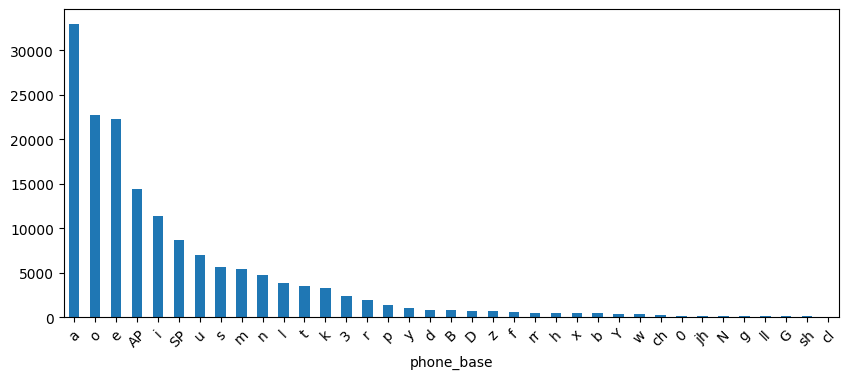

In [30]:
plt.figure(figsize=(10,4))
df_anotated_all['phone_base'].value_counts().plot.bar(rot = 45)

In [31]:
len(df_anotated_all['phone_base'])*0.02/60

53.20033333333333

In [32]:
df_anotated_all['song'].unique()

array(['ES_el_dia_que_naci_yo', 'ES_tu_que_vienes_a_rondarme',
       'CA_la_pastoreta', 'ES_milagro', 'ES_ventura2',
       'ES_lucero_de_la_maniana', 'ES_hildegart', 'CA_meteorit_ferit',
       'ES_quien_me_ama', 'CA_mabravasa', 'ES_volver_a_los_17',
       'CA_viola', 'ES_ventura', 'CA_impro', 'ES_negro_infinito',
       'CA_no_he_desitjat', 'CA_sol_solet', 'ES_jota', 'ES_galapaguito',
       'CA_impro2', 'ES_que_lejos_estoy_de_la_tierra', 'CA_xiqueta_meuna',
       'CA_impro3', 'ES_tras_de_ti', 'CA_sibi_la',
       'ES_la_sobra_de_la_luz', 'CA_un_gat_petit_tv3', 'CA_sol_solet-2',
       'ES_yo_vi_secarse_una_jara', 'CA_tu_saps'], dtype=object)

In [33]:
umap2 = u.train_umap(
        df_anotated_all,
        exclude_phones = ['SP'],
        n_components=2, 
        n_neighbors=100, 
        min_dist=0.1,
        save_model = False,
        folder = None)

df_proj2d = u.make_proj_anotated_feat_df(df_anotated_all, 
                                        umap2,
                                        save_df = False,
                                        folder = None)

          0         1         2         3         4         5         6  \
0  0.081733  0.141594  0.292011 -0.077799 -0.124914  0.101478  0.153100   
1  0.095223  0.190659 -0.100526 -0.020200 -0.276161  0.202057  0.334654   
2  0.174251  0.178408 -0.146670 -0.127853 -0.255945  0.279105  0.211511   
3  0.115133  0.210242 -0.142038 -0.074349 -0.283428  0.183395  0.212612   
4 -0.116070 -0.113691 -0.161191 -0.087346 -0.176419  0.317148 -0.227138   

          7         8         9  ...       761       762       763       764  \
0  0.080507 -0.307538 -0.290495  ...  0.129174 -0.147248 -0.081310 -0.073217   
1  0.203172 -0.054717 -0.021758  ... -0.118023 -0.148533  0.111579  0.183427   
2  0.183822 -0.131488 -0.087860  ... -0.025857 -0.183406  0.040749  0.259242   
3  0.172703 -0.169354 -0.017694  ... -0.088649 -0.184217  0.111834  0.164236   
4  0.181816 -0.345330 -0.198753  ...  0.272747 -0.081851 -0.034995 -0.023101   

        765       766       767  phone_base  duration  \
0 -0.018853

In [34]:
unique_phones = [k for k in df_proj2d['phone_base'].value_counts().keys() if k != 'SP']

Making a 2d plot


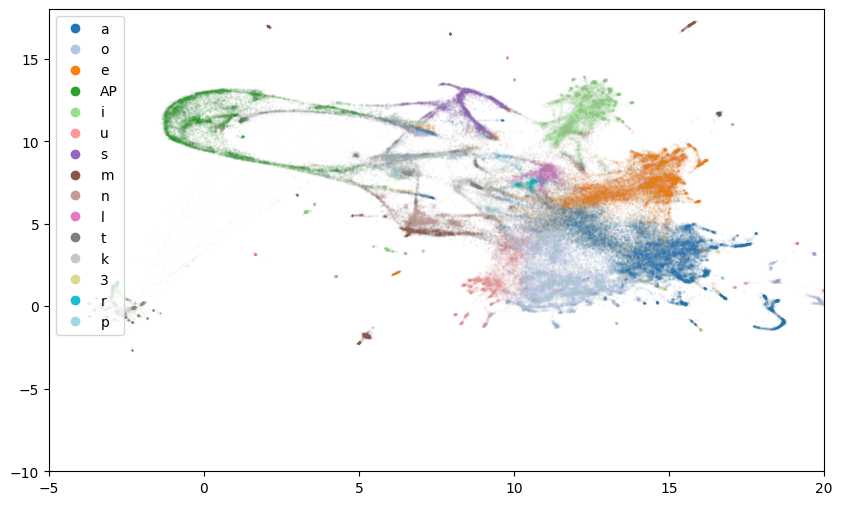

In [35]:
plots.make_tagged_LS_plot(df_proj2d,
            phones = unique_phones[:15],
            alpha = 0.1, 
            s = 0.1,
            show_global=True,
            xlim = [ -5, 20],
            ylim = [-10, 18])

In [ ]:
umap3 = u.train_umap(
        df_anotated_all,
        exclude_phones = ['SP'],
        n_components=3, 
        n_neighbors=100, 
        min_dist=0.1,
        save_model = False,
        folder = None)

           0         1         2         3         4         5         6  \
20 -0.075555 -0.031807  0.273665  0.104237  0.307026 -0.270532 -0.141782   
21 -0.035287 -0.088725  0.340239  0.092483  0.314589 -0.238668 -0.005882   
22  0.030404 -0.067610  0.294707  0.075899  0.308976 -0.235707 -0.042723   
23  0.016921 -0.085803  0.391042  0.076424  0.279585 -0.197127 -0.026308   
24  0.082183 -0.061017  0.419407  0.044994  0.221387 -0.255330  0.040530   

           7         8         9  ...       761       762       763       764  \
20  0.071121 -0.329375 -0.084599  ...  0.366452 -0.153630  0.353849 -0.231863   
21  0.164753 -0.463007 -0.002475  ...  0.286081 -0.193798  0.354715 -0.208412   
22  0.194393 -0.414545 -0.016340  ...  0.475442 -0.127864  0.288367 -0.223941   
23  0.168194 -0.351901 -0.031382  ...  0.444826 -0.161097  0.357280 -0.210967   
24  0.200517 -0.353849  0.004881  ...  0.342419 -0.076150  0.245099 -0.276393   

         765       766       767  phone_base  duration  

In [25]:
df_proj3d = u.make_proj_anotated_feat_df(df_anotated_all, 
                                        umap3,
                                        save_df = False,
                                        folder = None)

Applying dimensional reduction
Reduced to 3 dimensions
Finished computing projection. Transform time :168.92993712425232


Making a 3d plot


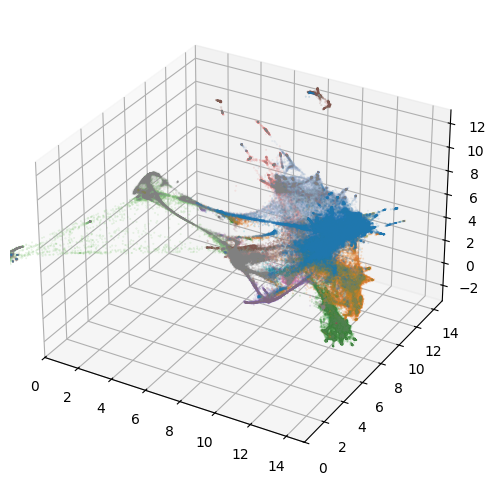

In [23]:
plots.make_tagged_LS_plot(df_proj3d,
            phones = unique_phones[:15],
            alpha = 0.25, 
            s = 0.1,
            show_global=True, 
            add_legend=False,
            xlim=[0,15],
            ylim=[0,15])

# edna MN comparison

In [36]:
import pandas as pd
#from pathlib import Path
import matplotlib.pyplot as plt

from phonetics import plots as plots

In [37]:
edna_file = '/Users/tomasandrade/Desktop/edna_result/df_proj_anotated_test.csv'
mn_file = '/Users/tomasandrade/Desktop/mn_result/df_proj_anotated_test.csv'

In [39]:
df_edna = pd.read_csv(edna_file, index_col=0)
df_mn = pd.read_csv(mn_file, index_col=0)

In [40]:
unique_phones = [k for k in df_mn['phone_base'].value_counts().keys() if k != 'AP']

In [41]:
df_edna

,x,y,phone_base,duration,song
0,11.203881,3.154828,a,0.027558,ES_el_dia_que_naci_yo
1,11.851193,3.112484,a,0.028118,ES_tu_que_vienes_a_rondarme
2,11.344858,4.550229,a,0.028118,ES_tu_que_vienes_a_rondarme
3,11.702501,4.090718,a,0.030835,ES_tu_que_vienes_a_rondarme
4,12.743072,3.880447,a,0.031738,ES_tu_que_vienes_a_rondarme
...,...,...,...,...,...
159596,5.369951,1.303985,cl,0.225850,ES_el_dia_que_naci_yo
159597,5.322581,1.722253,cl,0.225850,ES_el_dia_que_naci_yo
159598,10.048264,1.183334,cl,0.225850,ES_el_dia_que_naci_yo
159599,10.460029,0.906953,cl,0.225850,ES_el_dia_que_naci_yo


Making a 2d plot


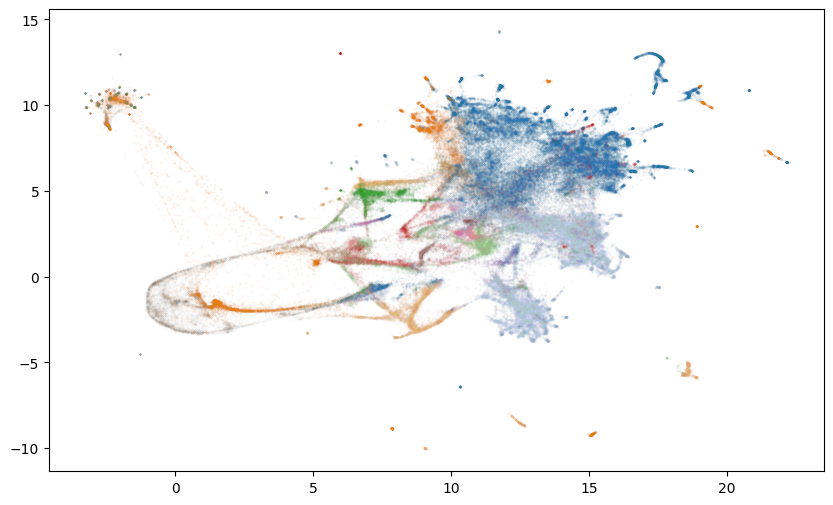

In [44]:
plots.make_tagged_LS_plot(df_edna,
            phones = unique_phones,
            alpha = 0.1, 
            s = 0.1,
            show_global=True,
            add_legend=False)

Making a 2d plot


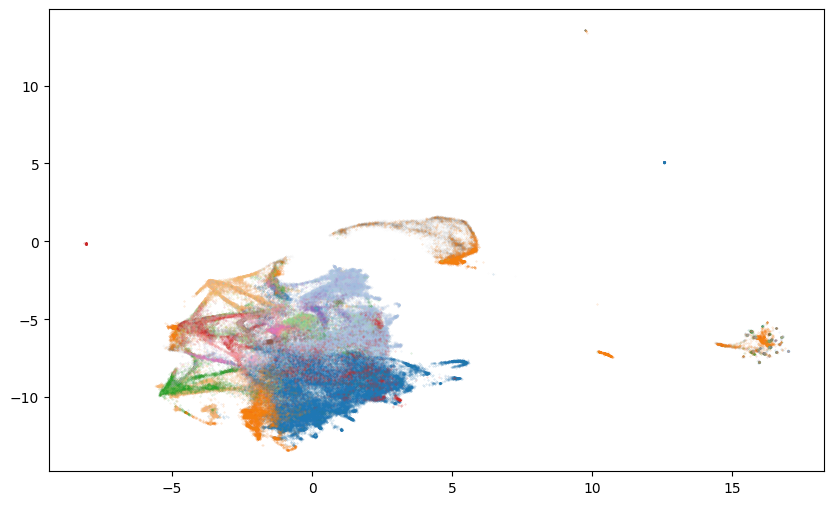

In [45]:
plots.make_tagged_LS_plot(df_mn,
            phones = unique_phones,
            alpha = 0.25, 
            s = 0.1,
            show_global=True,
            add_legend=False)